<div style="background:#FFFFEE; color:#440404; padding:8px; border-radius: 4px; text-align: center; font-weight: 500;">IFN619 - Data Analytics for Strategic Decision Makers</div>

# IFN619 :: UA1 - Assignment 1 - Foundational techniques (40%)

**IMPORTANT:** Refer to the instructions in Canvas module (`UA1 - Assignment 1`) *BEFORE* working on this assignment. Ensure that you are familiar with the marking rubric and understand how the grade for this assignment will be awarded according to the criteria.

1. Complete and run the code cell below to display your name and student number
2. Complete 2 full data analytics cylces as specified below (One for structured data, the other for semi-unstructured data). 
3. Ensure that you use ONLY the techniques and libraries/packages that have been used in class.
4. Ensure that you have addressed all of the criteria in the assignment rubric
5. Ensure that your notebook runs completey without errors
6. Clear all cells and re-run your entire notebook so that cells are sequentially numbered without any errors. **IMPORTANT: Not doing this step risks having your work marked as incomplete!**
7. Submit the clean notebook to Canvas **before** 11:55pm on the due date


**ESSENTIAL REQUIREMENTS:** Your task as a data analyst is to:

- Ensure that you use the techniques and libraries/packages that have been used in class
- Identify high quality questions that when answered may be helpful in addressing the provided scenario
- Clean and filter the data as appropriate
- Analyse the data in a way that answers important questions and ultimately addresses the concern in the scenario
- Visualise your results in a meaningful way that is helpful in making visible key findings
- Provide a detailed summary of the insights found and how they address the original questions and scenario
- Ensure that your analysis provides an effective narrative that directly addresses the scenario and answers the relevant questions

**AUTHENTICITY AND INTEGRITY**: You will be marked on (a) *HOW* you undertake the task todgether; with (b) detail of *WHY* you made various decisions involved in the tasks; and (c) acknowledgement of **WHERE** you  used material that is not directly yours. Therefore, **you must document your thinking and approach throughout the notebook using the Markdown cells, and give credit to other resources as appropriate.** You are encouraged to use the `Exemplars` PDF to help write your code. You may use online resources including `GenAI tools` and `stackoverflow` to help you write your code, however you must acknowledge that you are using these resources in the markdown cells explaining your analysis. Note that you do not need to use formal referencing for this.

---

In [1]:
# Complete the following cell with your details and run to produce your personalised header for this assignment

from IPython.display import HTML

first_name = 'Sepehr'
last_name = 'Amooeinejad'
student_number = 'N12631001'

personal_header = f"<h1>{first_name} {last_name} ({student_number})</h1>"
HTML(personal_header)

---

## Scenario for Assignment 1 and Assignment 2 (Part A)

You are working as a Data Scientist assisting the [Australian Sports Commission](https://www.ausport.gov.au) (ASC) in the lead-up to the [Brisbane 2032 Olympic Games](https://www.olympics.com/en/brisbane-2032/).

A recommendation needing investigation is for the ASC to build fan support for athletes over the next 6 years through strategically connecting with school age children and youth.

Your task is to investigage how relevant data might inform this strategy, particularly by taking advantage of the following suggestions:

1. Some school age children and yout (now) are likely to be Olympians in some sports offered in 2032. Tapping this peer connection could be a valuable part of the ASC strategy.
2. Some sports are highly popular with school age children and youth actively participating in them. There is potential to build fan support between athletes competing in these sports and kids participating in them.
3. Early adolescents will begin to use social media more in the next few years, and then be adults when the games occur. Connecting with this group may enable a steady build of wider social support which could boost the ASC strategy.


---
### Task 1 - Structured data analysis

Using only relevant parts of the data linked below, conduct a structured data analysis to address at least one aspect of the Scenario.

1. Question: Clearly articulate a relevant question (state why it is relevant)
2. Data: Import the data, and select relevant subdata, clean, and modify as necessary
3. Analysis: Analyse the data using the techniques and the Python packages used in class
4. Visualisation: Visualise your analysis in a way that is useful for the question (and relevant to the scenario)
5. Insights: Identify insights from your analysis which directly answer the question and help address the provided scenario.    

#### DATA URL:

[AusPlay results](https://www.ausport.gov.au/clearinghouse/research/ausplay/results)

#### FILE DOWNLOAD:

Scroll to `Data Tables: July 2024-June 2025` and download the file under the **Sport and activities** heading: `By Sport Data Tables - 13 November 2025`

#### IMPORT NOTE:

You may need to specify which data from which sheet you wish to import. You can use the following code as an example. It imports rows 158 - 300 from sheet 2 with specific column names:

```Python
df = pd.read_excel("C4S-AusPlay-By-Sport-Data-Tables-13-November-2025.xlsx",
                   sheet_name='2',
                   nrows=142,
                   skiprows=158,
                   header=None,
                   names=['total','C','males','females','G','0-4','5-8','9-11','12-14'])
```

---

# Introduction
---
## Context 
As a Data Scientist assisting ASC for 2032 Brisbane Olympic, I want to focus on building fan support between athletes competing in these sports and kids participating in them. based on what I Identified, the most relevant data is children's sport participation because:
- those children who are currently participating in sports are more likely to become sports fan in the future.
-  due to their age they are likely to be peers with Olympians of 2032 olympic, so they might have same background and even know them personally, which can form a greater fan bond.
-  15-17 group matter because not only they are still in school age, they are the first group who will access the social media because [Australia's social media ban for under-16s](https://www.abc.net.au/news/2025-12-10/australias-social-media-ban-for-under-16s-starts-today/106119800) and they have the advantage to promote the fan support using social media as well. Moreover, by 2032 Brisbane Olympics they'll be 21-23 so they can offer broader advocacy such as financial support.
-  0-4 group is excluded because by the time they are still too young for meaningful fan engagement because they are only 6-10 years old .

Additionally, the analysis only focuses on confirmed Brisbane Olympic sports as the goal is creating fan support for Olympics 

## Dataset
The Dataset I'm using is Ausplay by sport data table which was provided in the scenario assignment 1.
After going through the file I noticed it has 9 tables and out of them I chose the following tables to work on:
- Table 1: Participation by activity (adults)-Only column "15-17"
- Table 2: Participation by activity (children)-Whole table minus column "0-4"
- The list of confirmed [Brisbane 2032 Olympic sports](https://www.timeout.com/australia/news/your-ultimate-guide-to-the-brisbane-olympics-2032-dates-sports-venues-and-more-072325)

**By analyzing these tables I'll Identify which sports have the highest participation among these age groups, so that ASC can recognise which sports should be invested in order to have fan-athlete connections ahead of Brisbane 2032**



# Question

**Concern:** The Brisbane 2032 Olympic Games is happening in six years and [Australian Sports Commission](https://www.ausport.gov.au) wants to build fan support for athletes over the next 6 years through strategically connecting with school age children and youth because they're more likely to form a fan bond with athletes due to being peers and the fact that they'll be young adults by the time Olympics arrives. 

Creating a fan support can be costly and time consuming so it's important for ASC to find the most popular sports among children and youth in order to make more effective decisions and act in a timely manner. Moreover, because of the ban on social media for children under 16, the ASC should focus on building a foundation for Digital fan support targeting school-aged children who can access the social media, so that when other groups become 16+ they can join as well.

> **Question:** Which top 10 confirmed Brisbane 2032 Olympic sports have the highest estimated number of participants among children and youth aged 5-17 in Australia?

### Key Stakeholders

- **ASC** will make better decision based on the findings.
- **Government** will benefit politically from successful Brisbane 2032 and can provide funds for public sports infrastructure. Moreover, it is interested in children health.
- **Sport clubs** will receive more funding if ASC invests in their sport and will have more members as investment and promotion increases.
- **Professional Athletes playing in highly participated sports** will gain more fans and more funding

### Why this Question is significant

Due to the limited resources available (e.g. Time and Money) ASC needs to make targeted investment by identifying highly participated sports. These sports have higher priority because they already have large communities of active child participants who are natural fan candidates. Moreover, fan bond between children and Olympic Athletes is stronger due to the fact that they are peers and this question is considering children aged 15-17 which are the first group accessing social media so they'll be able to create digital fan support.

With Brisbane 2032 only six years away, if ASC acts now it will be able to accomplish its goal which is creating a fan support for athletes.

# Data

In [2]:
import pandas as pd
import plotly.express as px

Loading sheet 2 from AusPlay dataset which contains children participation data.

skipping 158 rows to skip the estimated participants section and capturing all the 142 remaining rows.

In [3]:
df_participation_number_child = pd.read_excel("C4S-AusPlay-By-Sport-Data-Tables-13-November-2025.xlsx",
                   sheet_name='2',
                   nrows=142,
                   skiprows=158,
                   header=None,
                   names=['Sports Name', 'total','C','males','females','G','0-4','5-8','9-11','12-14'])
df_participation_number_child

,Sports Name,total,C,males,females,G,0-4,5-8,9-11,12-14
0,Adventure racing,10801.585990,NaN,5283.216118,5518.369871,NaN,3298.108266,5010.809389,1375.268806,1117.399529
1,Air sports,12492.719563,NaN,9118.155065,3374.564498,NaN,4150.116075,4842.457771,0.000000,3500.145717
2,Archery,7143.730221,NaN,4764.652719,2379.077502,NaN,1763.974588,1123.266402,1198.697779,3057.791452
3,"Athletics, track and field",156335.213474,NaN,78086.015532,77648.012444,NaN,19677.159735,53332.220154,45772.153889,37553.679697
4,Australian football,304092.149879,NaN,226536.937876,76169.350409,NaN,20701.320908,121991.556433,83826.252144,77573.020394
...,...,...,...,...,...,...,...,...,...,...
137,Weight lifting,1176.609099,NaN,1176.609099,0.000000,NaN,0.000000,0.000000,632.770774,543.838325
138,Wheelchair rugby,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
139,Wood chopping,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
140,Wrestling,337.270004,NaN,337.270004,0.000000,NaN,0.000000,0.000000,0.000000,337.270004


[Droppeed](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) columns are:

Columns C and G are empty spacer from the excel formatting and contain no data.

Column 0-4 because the age group is excluded from the analysis as by the time of the Olympics they are still too young for meaningful fan engagement.

males and females column droped because they are not relevent to this analysis as well as not knowing exact number of those column for age 15-17 as it will contact to the rest of the dataframe

In [4]:
df_participation_number_child_cleaned= df_participation_number_child.drop(columns=['G', 'C','males', 'females', '0-4'])

In [5]:
df_participation_number_child_cleaned

,Sports Name,total,5-8,9-11,12-14
0,Adventure racing,10801.585990,5010.809389,1375.268806,1117.399529
1,Air sports,12492.719563,4842.457771,0.000000,3500.145717
2,Archery,7143.730221,1123.266402,1198.697779,3057.791452
3,"Athletics, track and field",156335.213474,53332.220154,45772.153889,37553.679697
4,Australian football,304092.149879,121991.556433,83826.252144,77573.020394
...,...,...,...,...,...
137,Weight lifting,1176.609099,0.000000,632.770774,543.838325
138,Wheelchair rugby,0.000000,0.000000,0.000000,0.000000
139,Wood chopping,0.000000,0.000000,0.000000,0.000000
140,Wrestling,337.270004,0.000000,0.000000,337.270004


There are 142 rows in the resulting dataframe showing sports with their participation number across selected age groups 5-8, 9-11 and 12-14

Loading sheet 1 from AusPlay dataset which contains adults participation data.

skipping 158 rows to skip the estimated participants section and capturing all the 142 remaining rows.

In [6]:
df_participation_number_adult = pd.read_excel("C4S-AusPlay-By-Sport-Data-Tables-13-November-2025.xlsx",
                   sheet_name='1',
                   nrows=142,
                   skiprows=158,
                   header=None,
                   names=['Sports Name', 'total','C','males','females','G', '15-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'
])
df_participation_number_adult

,Sports Name,total,C,males,females,G,15-17,18-24,25-34,35-44,45-54,55-64,65+
0,Adventure racing,4.240831e+04,NaN,31467.579622,7922.993964,NaN,3797.752253,17730.113402,11287.118274,5880.745046,3379.226061,333.355259,0.000000
1,Air sports,7.199320e+04,NaN,45732.065195,24290.205809,NaN,7383.342705,15952.787435,21349.895914,14896.147878,3343.948525,5265.326706,3801.747636
2,Archery,4.932956e+04,NaN,31697.959873,15660.679151,NaN,7031.045531,6359.345138,13572.313416,11112.053281,5170.716795,3775.284869,2308.805789
3,"Athletics, track and field",2.935784e+05,NaN,194047.135874,97560.355039,NaN,49060.452473,83965.898040,73521.596206,46224.976928,22295.174137,13498.557128,5011.761797
4,Australian football,5.891475e+05,NaN,443650.978919,142413.240366,NaN,62813.850512,160399.572038,190972.100788,105071.263481,48228.243495,19524.748302,2137.700955
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,Weight lifting,3.264980e+05,NaN,179331.335029,142810.611061,NaN,14194.412263,49699.796968,95048.398472,62241.917954,41228.740393,36417.572402,27667.154125
138,Wheelchair rugby,1.985336e+03,NaN,539.715112,1445.620728,NaN,0.000000,541.271657,1025.894416,0.000000,0.000000,418.169767,0.000000
139,Wood chopping,8.012935e+03,NaN,7332.001952,680.932611,NaN,0.000000,487.916162,0.000000,2327.105749,680.932611,2003.715048,2513.264992
140,Wrestling,1.211629e+04,NaN,10149.101469,1434.556326,NaN,1472.754415,2694.301638,4413.983411,1560.880037,1974.374567,0.000000,0.000000


Droppeed columns are:

Columns C and G are empty spacer from the excel formatting and contain no data.

All adult age groups except 15-17 are dropped because they fall outside the school-age range relevant to this analysis. The 15-17 group is retained because they are part of the analysis as they are in the school age range and have access to social media sooner.

total, males and females columns dropped as well because these are the sum of all adults age group so we can not use them as individuals. 

In [7]:
df_participation_number_adult_cleaned= df_participation_number_adult.drop(columns=['total', 'males', 'females', 'G', 'C','18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
df_participation_number_adult_cleaned

,Sports Name,15-17
0,Adventure racing,3797.752253
1,Air sports,7383.342705
2,Archery,7031.045531
3,"Athletics, track and field",49060.452473
4,Australian football,62813.850512
...,...,...
137,Weight lifting,14194.412263
138,Wheelchair rugby,0.000000
139,Wood chopping,0.000000
140,Wrestling,1472.754415


There are 142 rows in the resulting dataframe showing sports with their participation number for 15- 17 age group

Now I need to [merge()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) both datasets into one combined dataframe.
I used a left join on children data frame. there is probably no difference for joins as the sports names are identical, however I think it is the safest join as i want to preserve all the data in the children dataframe which is the  primary dataframe.
Additionally, i need to add the 15-17 estimation number to the total number in the combined version.

In [8]:
df_combined = df_participation_number_child_cleaned.merge(
    df_participation_number_adult_cleaned[["Sports Name", "15-17"]],
    on= 'Sports Name',
    how='left'
)
df_combined["total"] = df_combined["total"] + df_combined["15-17"]

In [9]:
df_combined

,Sports Name,total,5-8,9-11,12-14,15-17
0,Adventure racing,14599.338243,5010.809389,1375.268806,1117.399529,3797.752253
1,Air sports,19876.062268,4842.457771,0.000000,3500.145717,7383.342705
2,Archery,14174.775752,1123.266402,1198.697779,3057.791452,7031.045531
3,"Athletics, track and field",205395.665947,53332.220154,45772.153889,37553.679697,49060.452473
4,Australian football,366906.000391,121991.556433,83826.252144,77573.020394,62813.850512
...,...,...,...,...,...,...
137,Weight lifting,15371.021362,0.000000,632.770774,543.838325,14194.412263
138,Wheelchair rugby,0.000000,0.000000,0.000000,0.000000,0.000000
139,Wood chopping,0.000000,0.000000,0.000000,0.000000,0.000000
140,Wrestling,1810.024418,0.000000,0.000000,337.270004,1472.754415


df_combined now contains all the selected age groups with 142 sports and 8 columns
with the corrected total number of participants

In [10]:
print(df_combined['Sports Name'].tolist())

['Adventure racing', 'Air sports', 'Archery', 'Athletics, track and field', 'Australian football', 'Badminton', 'Baseball', 'Basketball', 'Baton twirling', 'Biathlon', 'Billiards/Snooker/Pool', 'BMX', 'Bobsledding', 'Bocce/Boules', 'Boccia', 'Body building', 'Boomerang throwing', 'Bowls', 'Boxing', 'Broomball', 'Bush walking', 'Calisthenics', 'Campdrafting', 'Canoeing/Kayaking', 'Circus', 'Cricket', 'Croquet', 'Crossfit', 'Curling', 'Cycling', 'DanceSport', 'Dancing (recreational)', 'Darts', 'Diving', 'Dodgeball', 'Dragon boat racing', 'Eight ball', 'Equestrian', 'eSports', 'Fencing', 'Fishing (recreational)', 'Fitness/Gym', 'Floorball', 'Flying disc', 'Football/soccer', 'Gaelic football', 'Geocaching', 'Goalball', 'Golf', 'Gridiron', 'Guides', 'Gymnastics', 'Handball', 'Harness racing', 'Hockey', 'Horse racing', 'Ice hockey', 'Ice racing/speed skating', 'Ice skating', 'Jet skiing', 'Judo', 'Jujitsu', 'Karate', 'Kendo', 'Kitesurfing/kiteboarding', 'Korfball', 'Kung fu wushu', 'Lacrosse

I compare both lists manually as there are some differences in naming for example Canoeing → 'Canoeing/Kayaking'/ Artistic Swimming → Synchronised swimming. Moreover, there is a shooting sport in the Olympic list however in the Ausplay dataset there is both 'Shooting/field' and 'Shooting/range' I decided to add their participants numbers together and label it as one (shooting) because the goal is to make a fan base for overall the sport if it ends up in top ten.
Interestingly the list provided by timeout australia contains 27 sports from which only 26 of them exist in the Ausplay dataset and there isn't any  Marathon Swimming data in it.

Additionally, cross-referencing with the [International Handball Federation](https://www.ihf.info/media-center/news/road-brisbane-2032-olympic-games-starts-now-australia) IHF confirms that Handball is a confirmed core Olympic sport for Brisbane 2032 but was missing from the Timeout Australia list, bringing the total to 28 confirmed core sports.

so now Olympic sports list contains 27 sports.

Note that the final Brisbane 2032 sports programme will be confirmed in 2026, so this analysis uses the confirmed core sports as a baseline.

now I need to check what sports the dataframe covers and filter them with Olympic sports 
based on the [Timeout Australia](https://www.timeout.com/australia/news/your-ultimate-guide-to-the-brisbane-olympics-2032-dates-sports-venues-and-more-072325)
The Olympic sports are:

Athletics, Aquatics (Swimming, Diving, Water Polo, Artistic Swimming, Marathon Swimming), Badminton, Basketball, Boxing, Canoeing, Cycling, Equestrian, Fencing, Football/Soccer, Gymnastics, Judo, Modern Pentathlon, Rowing, Sailing, Shooting, Table Tennis, Taekwondo, Tennis, Triathlon, Volleyball, Weightlifting, Wrestling

In [11]:
olympic_sports = [
    'Athletics, track and field',
    'Swimming',
    'Diving',
    'Water polo',
    'Synchronised swimming',
    'Badminton',
    'Basketball',
    'Boxing',
    'Canoeing/Kayaking',
    'Cycling',
    'Equestrian',
    'Fencing',
    'Football/soccer',
    'Gymnastics',
    'Handball',
    'Judo',
    'Modern pentathlon',
    'Rowing',
    'Sailing',
    'Shooting/field',
    'Shooting/range',
    'Table tennis',
    'Taekwondo/Taekwon-do',
    'Tennis',
    'Triathlon',
    'Volleyball (indoor and outdoor)',
    'Weight lifting',
    'Wrestling'
]
len(olympic_sports)

28

filtering the df_combined with the olympic_sports using [df.isin()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html) keeping only rows where the Sports Name appears in the olympic_sports list.

In [12]:
df_olympic = df_combined[df_combined["Sports Name"].isin(olympic_sports)]
df_olympic

,Sports Name,total,5-8,9-11,12-14,15-17
3,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
5,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
7,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
18,Boxing,3.105555e+04,3847.392572,5355.226062,7166.201064,13532.802886
23,Canoeing/Kayaking,1.855113e+04,743.323304,1899.941670,1949.046671,12637.185008
29,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
33,Diving,3.721311e+03,662.703109,1178.515645,1113.936981,0.000000
37,Equestrian,1.782911e+04,2971.942781,5792.408187,2419.023003,3606.626338
39,Fencing,8.220364e+03,0.000000,520.994140,1944.387221,3644.160673
44,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438


Converting two shooting rows into one shooting row as we are interested in shooting number of participants number.

In [13]:
shooting_total = df_olympic[df_olympic['Sports Name'].isin(['Shooting/field', 'Shooting/range'])]
shooting_total

,Sports Name,total,5-8,9-11,12-14,15-17
110,Shooting/field,4806.364674,0.0,650.112699,772.653128,3383.598847
111,Shooting/range,1899.251514,0.0,490.134545,1409.116968,0.000000


here are the original rows  first i need to select them then sum each column values together.

In [14]:
shooting_total = df_olympic[df_olympic['Sports Name'].isin(['Shooting/field', 'Shooting/range'])][['total','5-8','9-11','12-14','15-17']].sum()
# creating a new row/ ** fetch all the list content 
row = pd.DataFrame([{'Sports Name': 'Shooting', **shooting_total}])
df_olympic = pd.concat([df_olympic, row], ignore_index=True)
df_olympic

,Sports Name,total,5-8,9-11,12-14,15-17
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
3,Boxing,3.105555e+04,3847.392572,5355.226062,7166.201064,13532.802886
4,Canoeing/Kayaking,1.855113e+04,743.323304,1899.941670,1949.046671,12637.185008
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
6,Diving,3.721311e+03,662.703109,1178.515645,1113.936981,0.000000
7,Equestrian,1.782911e+04,2971.942781,5792.408187,2419.023003,3606.626338
8,Fencing,8.220364e+03,0.000000,520.994140,1944.387221,3644.160673
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438


In [15]:
#removing Shooting/field and Shooting/range from the dataframe/ ~ not operator
df_olympic = df_olympic[~df_olympic['Sports Name'].isin(['Shooting/field','Shooting/range'])]
# reseting index
df_olympic = df_olympic.reset_index(drop=True)
df_olympic

,Sports Name,total,5-8,9-11,12-14,15-17
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
3,Boxing,3.105555e+04,3847.392572,5355.226062,7166.201064,13532.802886
4,Canoeing/Kayaking,1.855113e+04,743.323304,1899.941670,1949.046671,12637.185008
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
6,Diving,3.721311e+03,662.703109,1178.515645,1113.936981,0.000000
7,Equestrian,1.782911e+04,2971.942781,5792.408187,2419.023003,3606.626338
8,Fencing,8.220364e+03,0.000000,520.994140,1944.387221,3644.160673
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438


The data prepration is done.

The datafram *df_olympic* contains 27 confirmed Brisbane 2032 Olympic sports with estimated participation number across age groups 5-8, 9-11, 12-14 and 15-17.The total column represents the combined estimated number of participants across all selected age groups (5-17). 

# Analysis 

Sorting the df_olympic dataframe based on the total number of estimated participants (age 5-17) to find top ten most participated sports among children and teenagers. this analysis helps ASC to find what Olympic sports are most popular and prioritize investment based on the findings using [sort_values()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) to sort in descending order and [head()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html) to select top 10 records

In [36]:
df_olympic_ordered = df_olympic.sort_values("total", ascending= False)
df_olympic_ordered
df_olympic.to_csv('data/df_olympic.csv', index=False)

 ** Estimate has relative margin of error greater than 100% and is considered too unreliable to use. Interestingly, Modern pentathlon has **0 participants something to be considered in the future invastigation.

In [17]:
df_olympic_top10 = df_olympic_ordered.head(10)
df_olympic_top10

,Sports Name,total,5-8,9-11,12-14,15-17
16,Swimming,1.323228e+06,424759.815446,265815.783005,108559.479291,186302.288937
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
10,Gymnastics,3.641937e+05,142163.816180,72125.780284,27759.478988,22203.923642
20,Tennis,2.814891e+05,58743.511659,61724.961711,59618.501852,89227.483055
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
22,Volleyball (indoor and outdoor),1.305467e+05,2362.972667,10068.970234,21437.663434,94899.795756
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
18,Table tennis,7.318636e+04,3724.874723,8254.518613,8912.065230,51713.237670


after checking values with the Ausplay database I noticed that the following data points have a relative margin of error between 50% and 100% and should be used with caution based on the footnote.
- Volleyball (indoor and outdoor): 5-8 age group (2,362)
- Badminton: 5-8 age group (7,797) and 9-11 age group (7,244)
- Table tennis: 5-8 age group (3,724) and 9-11 age group (8,254)

The values are marked with * in the dataset.
However the total number of them isn't marked.

For visualization I chose [bar chart]( https://plotly.com/python-api-reference/generated/plotly.express.bar.html) because I need to compare different categories (sports name) based on their participation numbers and the bar chart is the best option for that

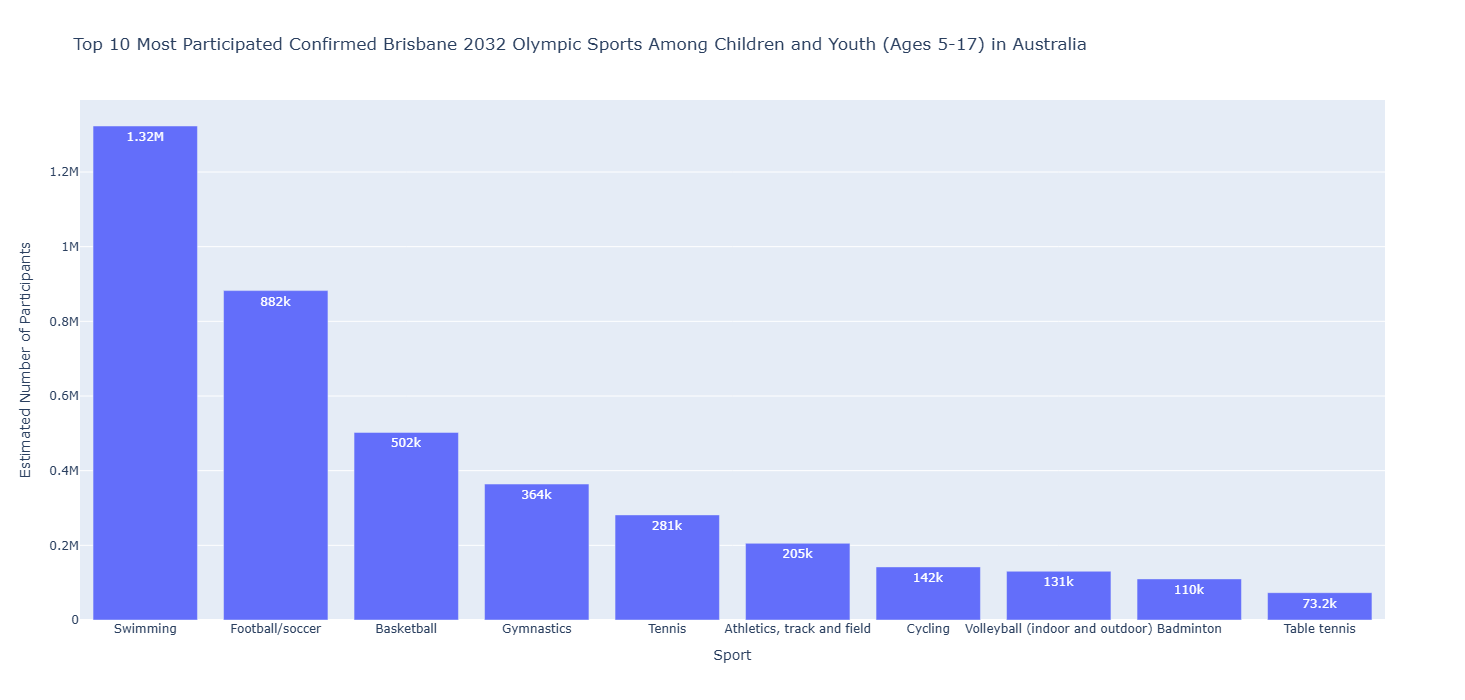

In [18]:
fig = px.bar(
    df_olympic_top10,
    x= 'Sports Name',
    y= 'total',
    title= "Top 10 Most Participated Confirmed Brisbane 2032 Olympic Sports Among Children and Youth (Ages 5-17) in Australia",
    labels={'total': 'Estimated Number of Participants', 
            'Sports Name': 'Sport'},
     text_auto='.3s', #shows values for each sport
    height= 700,
    width= 1200
)
fig.show()

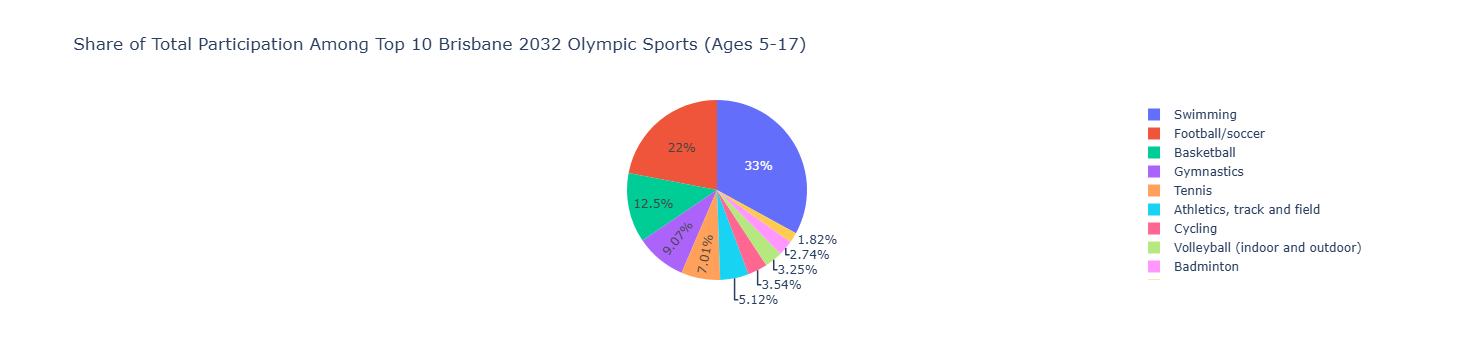

In [19]:
fig_pie = px.pie(
    df_olympic_top10,
    values='total',
    names='Sports Name',
    title='Share of Total Participation Among Top 10 Brisbane 2032 Olympic Sports (Ages 5-17)'
)
fig_pie.show()

based on the observation the top three sports are Swimming, Football/soccer and Basketball with more than 2.7 million participants combined. The overall bar chart showes that there is a gradual decline in number of participants and the swimming is so predominant that the 7 less participants sports combined can not reach it making it the most favourable sport among children and youth

# Analysis (part 2)

Now that I have top ten most participated sport, in the second analysis I want to focus on how participations is distributed across age groups within sports.

This analysis provides the ASC with more targeted insights about which group to focus on for each sport.

# Visualisation

For the visualisation I stick to the bar chart however a stacked one. I could use a line chart as well however as age groups are discrete categories it could look cluttered. 

Moreover, for making that plot I need to convert my dataframe as now the groups are columns and they needed to be in the rows so i need to convert my wide table to a long table using [melt()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.melt.html)

In [20]:
df_olympic_top10

,Sports Name,total,5-8,9-11,12-14,15-17
16,Swimming,1.323228e+06,424759.815446,265815.783005,108559.479291,186302.288937
9,Football/soccer,8.822976e+05,239439.897817,217361.968928,161372.963119,181202.174438
2,Basketball,5.024981e+05,97252.948855,105177.424498,124325.819536,160131.829928
10,Gymnastics,3.641937e+05,142163.816180,72125.780284,27759.478988,22203.923642
20,Tennis,2.814891e+05,58743.511659,61724.961711,59618.501852,89227.483055
0,"Athletics, track and field",2.053957e+05,53332.220154,45772.153889,37553.679697,49060.452473
5,Cycling,1.422156e+05,29391.657772,18700.215850,15343.821911,59186.917667
22,Volleyball (indoor and outdoor),1.305467e+05,2362.972667,10068.970234,21437.663434,94899.795756
1,Badminton,1.100375e+05,7797.761540,7244.605036,14028.111061,73825.687440
18,Table tennis,7.318636e+04,3724.874723,8254.518613,8912.065230,51713.237670


In [21]:
melted_df_olympic_top10 = df_olympic_top10.melt(
    id_vars= 'Sports Name', # which column identifies each sport
    value_vars= ['5-8','9-11','12-14','15-17'], # which columns are age groups
    var_name= "Age groups",
    value_name= "number of participants"
)
melted_df_olympic_top10

,Sports Name,Age groups,number of participants
0,Swimming,5-8,424759.815446
1,Football/soccer,5-8,239439.897817
2,Basketball,5-8,97252.948855
3,Gymnastics,5-8,142163.816180
4,Tennis,5-8,58743.511659
5,"Athletics, track and field",5-8,53332.220154
6,Cycling,5-8,29391.657772
7,Volleyball (indoor and outdoor),5-8,2362.972667
8,Badminton,5-8,7797.761540
9,Table tennis,5-8,3724.874723


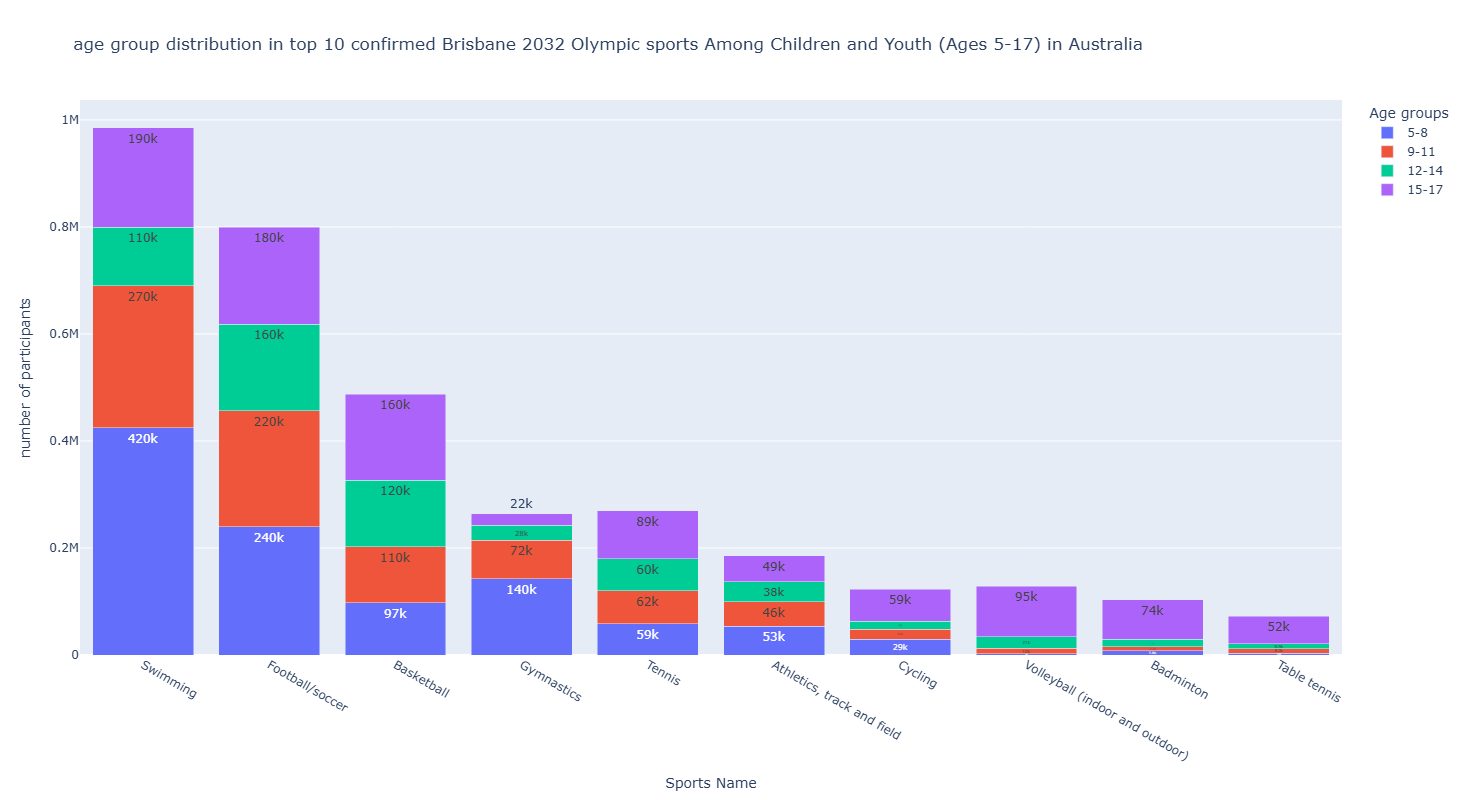

In [22]:
fig2 = px.bar(
    melted_df_olympic_top10,
    x= 'Sports Name',
    y= 'number of participants',
    color= 'Age groups',
    barmode= 'stack',
    title= 'age group distribution in top 10 confirmed Brisbane 2032 Olympic sports Among Children and Youth (Ages 5-17) in Australia',
    width=1200,
    height=800,
    text_auto='.2s'
)
fig2.show()

The plot is not realy informative so I decided to group the bar chart using facet_col and I need to do some [annotation](https://plotly.com/python/facet-plots/)

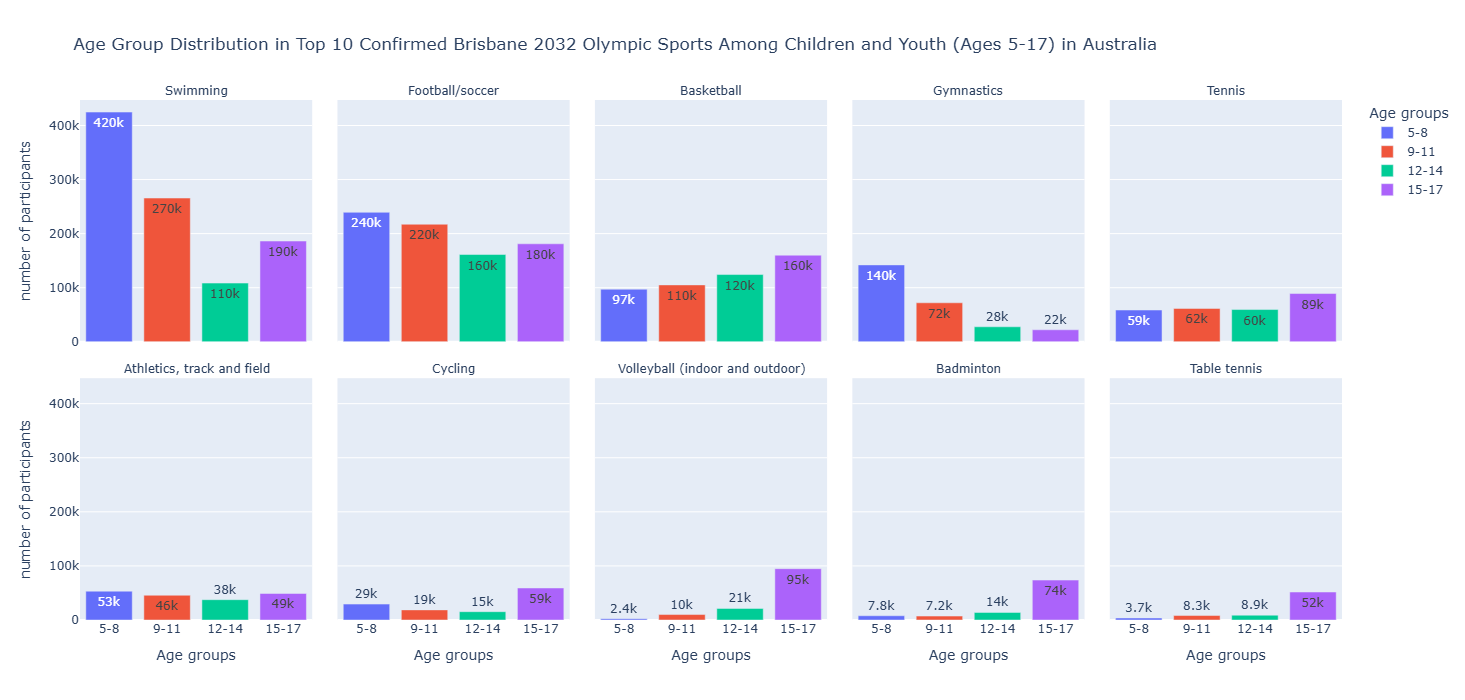

In [23]:
fig3 = px.bar(
    melted_df_olympic_top10,
    x='Age groups',
    y='number of participants',
    color='Age groups',
    facet_col='Sports Name',
    facet_col_wrap=5,
    title='Age Group Distribution in Top 10 Confirmed Brisbane 2032 Olympic Sports Among Children and Youth (Ages 5-17) in Australia',
    height=700,
    width=1200,
    text_auto='.2s'
)
fig3.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig3.show()

Based on the new observation you can put sports in four categories. 
- Increasing with age: Basketball, Volleyball, Badminton, Table tennis
- Decreasing with age: Gymnastics
- Relatively stable: Athletics, track and field, Tennis, Cycling
- Mixed/unclear trend (U shaped): Football/soccer, Swimming

# Insights

#### Which top 10 confirmed Brisbane 2032 Olympic sports have the highest estimated number of participants among children and youth aged 5-17 in Australia?
1. Swimming
2. Football/soccer
3. Basketball
4. Gymnastics
5. Tennis
6. Athletics, track and field
7. Cycling
8. Volleyball (indoor and outdoor)
9. Badminton
10. Table tennis

#### what are the Age group trends?
based on the analysis there are four trend categories for these sports: 
- Mixed/unclear trend (U shaped): Football/soccer, Swimming
- Increasing with age: Basketball, Volleyball, Badminton, Table tennis
- Decreasing with age: Gymnastics
- Relatively stable: Athletics, track and field, Tennis, Cycling

#### Strategic recommendations for ASC
This analysis suggest that the ASC eemphasize more on these sports when investing for creating a fan support as they are top 10 most participated confirmed sports for 2032 Brisbane. However, Since participation patterns differ significantly across sports, a one-size-fits-all approach would be ineffective and ASC should implement different strategies based on the trends. 
- for increasing with age category, ASC should target older age groups (12-14 and 15-17) for fan connection in these sports
- for decreasing with age category, ASC should target younger age groups 5-8 before participation drops off
- for stable category consistent investment across all age groups is advised
- for mixed/unclear trend, the ASC should implement the same strategy as stable category because Swimming (1.32M) and Football/soccer (882k) combined account for more than half of total participation across all top 10 sports

#### Data Limitation
- There is a margin of error (50%-100%) for specific age groups of sports (Volleyball, Badminton, Table tennis)
- due to the lack of participation number for female and male for each age group I couldn't have a gender based analysis as I didn't have related data for 15-17 age group
- The Brisbane 2032 sports programme is still being finalised in 2026 so at the time of analysis there wasn't any confirmed official sports for the Olympic.

#### How analysis could be improved
- with larger sample sizes the margin of error for smaller sports will be reduced
- gender data for 15-17 age group would help to have a gender based analysis
- The analysis should be updated as the official Brisbane 2032 sports is confirmed

---
# Task 2 - Semi/unstructured data analysis

Using only relevant parts of the data specified below, conduct a semi/unstructured data analysis to address at least one aspect of the Scenario.

1. Question: Clearly articulate a relevant question (state why it is relevant)
2. Data: Access and import the data, select relevant subdata, clean, and modify as necessary
3. Analysis: Analyse the data using the techniques and the Python packages used in class
4. Visualisation: Visualise your analysis in a way that is appropriate for semistructured data, useful for the question, and relevant to the scenario.
5. Insights: Identify insights from your analysis which directly answer the question and help address the provided scenario.    

**DATA LOCATION:** 
[Guardian API]((https://open-platform.theguardian.com/access/))

**SEARCH PARAMETERS:**
Create a search that is relevant to at least one of the 3 suggestions in the scenario. Ensure that you explain why your search is relevant, and helpful to addressing the scenario.

# Question

**Concern:** As we are living in a digital age, social media has become an inseparable part of our lives, connecting us to the world. The Brisbane 2032 Olympics is a major global event which makes the social media a tool for advertisement and advocacy. However, social media ban for under 16 brings challenges especially for ASC trying to create a fan base for Brisbane 2032. By understanding key themes in media coverage regarding this issue, ASC can plan ahead using this disadvantage as an opportunity creating a base for fan engagement so when the 10-15 years old reach the eligible age they can use it for digital advocacy during the games
> **Question:** What are the key themes in Guardian Australia's coverage of the Australian social media ban for under-16s, and what does this reveal about opportunities and challenges for the ASC's digital fan support strategy ahead of Brisbane 2032?

### Key Stakeholders

- **ASC**: It will make better decision based on the findings.
- **Government**: It will benefit politically from successful Brisbane 2032 , social media and fan support play a huge part advertising this event and can influence people opinions regarding it.
- **Social media platforms in AU**: the law directly influence social media platforms
- **Teenagers**: social media ban limits their access to social media platforms and they're the targeted audiences for ASC's fan engagement plan

### Why this Question is significant
The social media ban can affect under 16 lives as they cannot be as active online as they used to. With this free time The ASC can direct teenagers to more offline activities especially sports and fan engagement activities. So by understanding key themes ASC can move accordingly using it for attracting youth to sports.

# Data

For data section I'm using the Accessing_the gaurdian file and save the results inside of a json file.
I set the from date  since september 2024 brcause [in September 2024, Australian Prime Minister Anthony Albanese announced plans to introduce laws banning children under 16 from social media.](https://www.amnesty.org.au/social-media-ban-explained) so I wanted to check what was the discussions regarding to it after this announcement.

for my search string I choosed key words related to my question which were social media, age ban and Australia

productions office is set the aus as I only want Australian point of view and their media covarage 

I recieved 49 articles regarding my request and saved them inside of social_media_ban_articles.json to have a constant file to run my analysis 

not all the articles are related to my question and I need to do some cleaning


In [24]:
# build a search URL
# base_url = 'https://content.guardianapis.com/'

# search_string = '"social media" AND "age ban" AND Australia'

# production_office = "aus"

# from_date = "2024-09-01"
# to_date = "2026-04-07"

# full_url = base_url+f"search?q={search_string}&production-office={production_office}&from-date={from_date}&show-fields=body&api-key={key}"
# print(full_url[:120])

In [25]:
file_name = "social_media_ban_articles.json"

with open(file_name,'r', encoding='utf-8') as fp:
    articles = json.load(fp)

print(f"Loaded {len(articles)} articles from {file_name}")

Loaded 49 articles from social_media_ban_articles.json


for filtering I want the titles to have at least one of the following:
- social media
- age ban
- under-16

then I want to remove any title that has 'as it happened in it as they are live blogs covering multiple topics so it is not realy helpful


In [26]:
filtered_articles = {
    title: text for title, text in articles.items()
    if ('social media' in title.lower() 
    or 'age ban' in title.lower() 
    or 'under-16' in title.lower())
    and 'as it happened' not in title.lower()
}
print(len(filtered_articles))

15


In [27]:
for title in filtered_articles.keys():
    print(title)
    print(filtered_articles[title])

Social media makes many Australian teens feel worse about their bodies. Platforms must take responsibility | Zoe Daniel [2025-12-13T19:00:40Z]
Soon after the 2022 election a woman came into my electorate office to tell me about her teenage daughter. She spoke about her family’s journey through anorexia, the lack of effective and available medical support and treatment, about her child being held down by security guards for forced refeeding in hospital, the compounding mental health issues for the whole family, the financial and marital pressure as she tried to keep her child alive. It soon became very clear that hers wasn’t the only story. One of the most deadly  mental illnesses, eating disorders among those aged 10 to 19 have risen by 86% since 2012, roughly coinciding with the rise of social media and, in the latter period, Covid. In 2020, for example, the number of admissions to the ED unit at Monash Children’s hospital in Melbourne were more than double mean annual admissions in 2

In [28]:
first_title = list(filtered_articles.keys())[0]
print(first_title)
print(filtered_articles[first_title][:200])

Social media makes many Australian teens feel worse about their bodies. Platforms must take responsibility | Zoe Daniel [2025-12-13T19:00:40Z]
Soon after the 2022 election a woman came into my electorate office to tell me about her teenage daughter. She spoke about her family’s journey through anorexia, the lack of effective and available me


# Analysis

Base of the course materials there are two common approaches for text analysis (Count and TF-IDF).
- count: it counts the word frequency
- TF-IDF looks for rare but meaningful words and give them higher scores compared to common words.
As we are looking for most talked about themes regarding to age ban I believe count is much suitable for this analysis
max_Df is set to 0.85 I started with 0.8 to 0.9 but i chose 0.86 as i want the word to be at maximnum 13 articles to avoid universal words among all 15 articles
min_df is set to 2 so the word must appear in at least 2 articles to be considered in the analysis
max_features is set to 500 for now if it was sufficient I won't change it 

In [29]:
# Code adapted from IFN619 B3 course materials
from sklearn.feature_extraction.text import CountVectorizer


count_vectorizer = CountVectorizer(
    max_df=0.86,
    min_df = 2, 
    max_features=500,
    stop_words="english" # removing common english words 
)

now I will feed it with the articles

In [30]:
count_dt_matrix = count_vectorizer.fit_transform(filtered_articles.values())

In [31]:
feature_names = count_vectorizer.get_feature_names_out()
feature_names

array(['000', '10', '11', '12', '14', '15', '16', '16s', '17', '18',
       '2024', '25', 'ability', 'able', 'abuse', 'access', 'accessing',
       'account', 'accounts', 'act', 'action', 'activist', 'address',
       'adopt', 'adult', 'adults', 'advocates', 'aged', 'ages',
       'agreement', 'albanese', 'alcohol', 'algorithms', 'allow',
       'allows', 'amendments', 'amp', 'andrew', 'announced', 'anthony',
       'app', 'applied', 'apply', 'appropriate', 'apps', 'arguing',
       'arrangements', 'asking', 'associated', 'assurance', 'australian',
       'australians', 'available', 'backed', 'bail', 'bank', 'banning',
       'barr', 'based', 'benefits', 'best', 'better', 'big', 'block',
       'blunt', 'body', 'breaking', 'called', 'calling', 'came',
       'campaign', 'care', 'centre', 'certification', 'chair', 'change',
       'changes', 'check', 'checking', 'chief', 'child', 'cited', 'clear',
       'climate', 'coalition', 'come', 'commissioned', 'commissioner',
       'committee',

count_dt_matrix.toarray() gives me an array each row is an article and each column is a word now I want to sum each column to find out top repeated words then creating a data frame showing the word an its frequency

In [32]:
word_counts = count_dt_matrix.toarray().sum(axis=0)

word_frequency = pd.DataFrame({
    'word': feature_names,
    'count': word_counts
})
word_frequency

,word,count
0,000,7
1,10,4
2,11,4
3,12,6
4,14,10
...,...,...
495,years,5
496,young,58
497,younger,4
498,youth,7


nwo that I have the frequency for each word I need to sort them based of it

In [33]:
word_frequency = word_frequency.sort_values('count', ascending=False)
top30 = word_frequency.head(30)
top30['word']

496          young
281       minister
252    legislation
50      australian
30        albanese
366         report
49       assurance
91       companies
232           just
310     parliament
363        related
302         online
494           year
295            new
458          trial
473          users
15          access
267           make
127        digital
309        parents
191       guardian
6               16
441     technology
102        content
196           harm
200         health
221      instagram
88       committee
491          world
275         mental
Name: word, dtype: str

# Visualisation

For visualization I'm using a horizental bar chart because I don't want the word to overlap each other make the chart messy. 

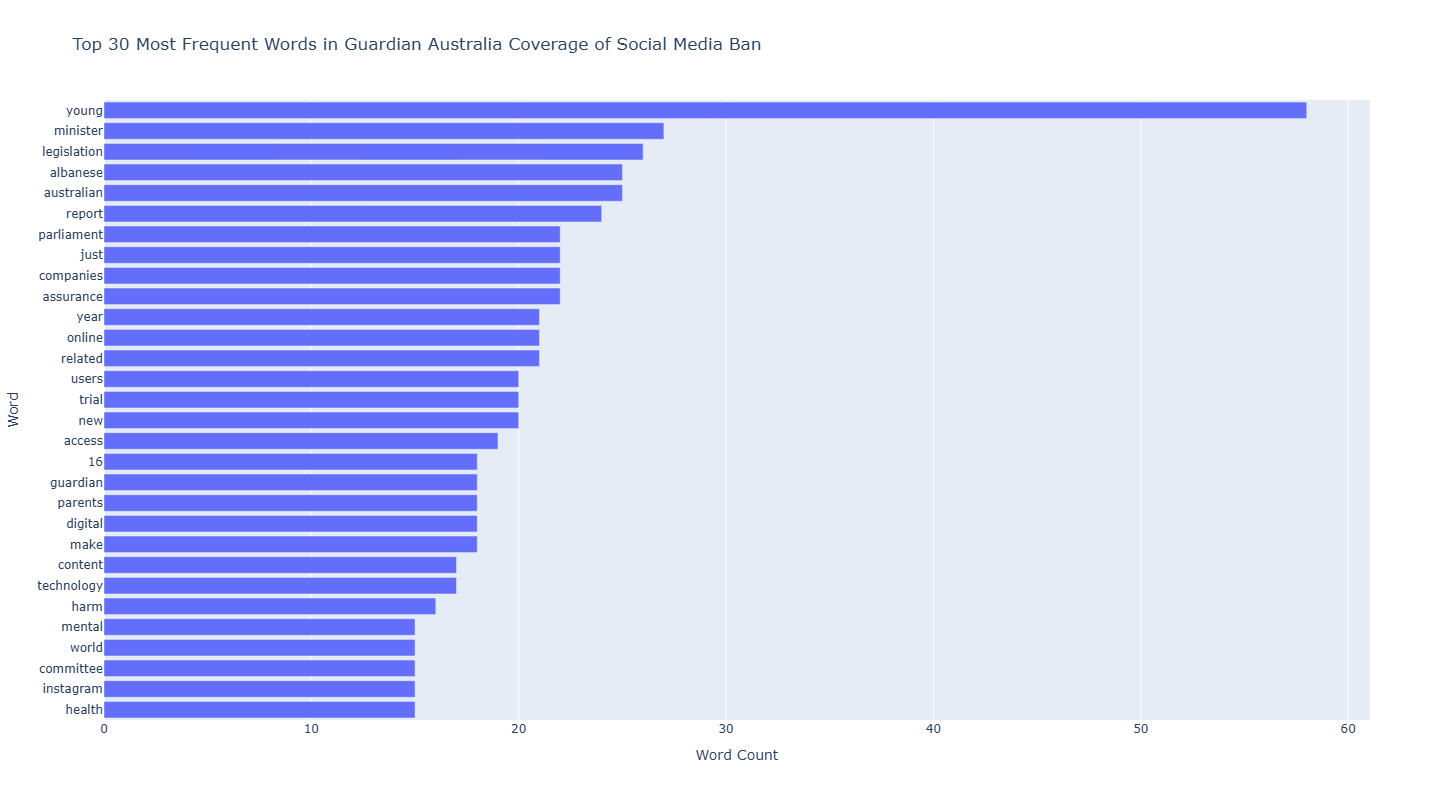

In [34]:
fig = px.bar(
    top30,
    x='count',
    y='word',
    orientation='h',
    title='Top 30 Most Frequent Words in Guardian Australia Coverage of Social Media Ban',
    labels={'count': 'Word Count', 'word': 'Word'},
    height=800,
    width=1000
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

The chart shows that the "young" word is the dominant word across articles showing how the coverage is focused on certain age group (under 16) that is influenced by this ban.

Theme clustering was identified with assistance from Claude.ai (claude.ai) and here are the identified theme clusters:
- Political & Legislative Process: minister(27), legislation(26), albanese(25), australian(25), report(24), parliament(22), committee(15)
- Implementation & Enforcement: assurance(22), companies(22), online(21), users(20), trial(20), access(19), digital(18), technology(17)
- Wellbeing & Harm: harm(16), health(15), mental(15), content(17)  
- Social Media Platforms: instagram(15)
- People & Community: young(58), parents(18), guardian(18), 16(19)
- Noise words: make, new, year, just, related, world

the noise words will be removed from analysis and I will focus on the first five themes.

# Insights

#### key findings:
The analysis of 15 Guardian Australia articles about the social media ban reveals five key themes (the number infront of each theme represents the sum of words count) in a descending order:
1. Political & Legislative Process — 164
2. Implementation & Enforcement — 159
3. People & Community — 113
4. Wellbeing & Harm — 63
5. Social Media Platforms — 15

"Political & Legislative Process" and "Implementation & Enforcement" are dominant themes in media coverage which isn't an odd outcome considering that the set date is from the date prime minister announced his plan regarding to social media ban. These themes shows that there were political debates regarding the law and coverage of the Implementation and enforcement during the time. the third and fourth themes are regarding to whom and how the contents on social media can effect,which are heavily focused on youth and mental health problems.

#### Strategic recommendations for ASC
Social media ban brings its own challenges for ASC as it makes harder for it to create a digital fan support especially in this digital age by limiting the access of youth to social media. However, based on the findings the main themes in media coverage are youth and wellbeing showing how media was concerned regarding to effects social media can have on children and teenagers which led to this ban. The ASC can use this as an advantage, promoting physical activities (sports) as an alternative for children which can help them to be more active, sociable and boost their mental health which leads to higher number of participants in sports. Moreover, based on the dominant themes the ASC can use the political debate as a leverage getting more funds from government for its activities.

Notably, Swimming and Football/soccer — the top two most participated sports among children aged 5-17 from the structured analysis — are exactly the type of physical activities the ASC could promote as alternatives to social media.

#### Data Limitation
- We are only using one source for our data which is Guardian API this has led to small sample size which affect the findings. Moreover, it has biases as we are using one news outlet which has specific political point of view.
- the clustering was done manually with AI assistance this can have its own limitation as the sample size grows.
- date was from the date the prime minister introduced its plan (september 2024), missing coverage that lead to this plan
- some noise words weren't captured by the stopwords filter

#### How analysis could be improved
- using different news outlets for gathering data
- using other analysis tools such as [Automated topic modelling](https://www.geeksforgeeks.org/nlp/what-is-topic-modeling/) for  identifying themes and [Sentiment analysis](https://www.geeksforgeeks.org/machine-learning/what-is-sentiment-analysis/) to understand the emotional tone of the articles 